In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import math

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# --- CẤU HÌNH ---
N_PAST = 30         # 30 ngày quá khứ
N_FUTURE_TRAIN = 1  # Train dự báo 1 ngày
DAYS_TO_PREDICT = 7 # Dự báo 7 ngày (Recursive)

# Danh sách 8 features cần dự báo
TARGET_COLS = [
    'surface_pressure_mean', 
    'wind_speed_10m_mean',
    'cloudcover_mean', 
    'temperature_2m_mean', 
    'relative_humidity_2m_mean',
    'rain_sum',
    'precipitation_hours',
    'weather_code'
]

# --- XỬ LÝ ĐƯỜNG DẪN THÔNG MINH ---
current_dir = os.getcwd()
print(f"Thư mục hiện tại: {current_dir}")

if current_dir.endswith('src'):
    # Nếu đang ở trong src, phải lùi ra ngoài 1 cấp
    BASE_DATA_DIR = '../data/processed/'
    BASE_MODEL_DIR = '../models/rnn_recursive/'
else:
    # Nếu đang ở root
    BASE_DATA_DIR = 'data/processed/'
    BASE_MODEL_DIR = 'models/rnn_recursive/'

# Tạo thư mục lưu nếu chưa có
if not os.path.exists(BASE_MODEL_DIR):
    os.makedirs(BASE_MODEL_DIR)
    
print(f"Dữ liệu sẽ đọc từ: {BASE_DATA_DIR}")
print(f"Model sẽ lưu vào: {BASE_MODEL_DIR}")

Thư mục hiện tại: c:\Users\add\OneDrive - Trường ĐH CNTT - University of Information Technology\Tài liệu\CS313\CS313-Predict-weather-7-days-in-VietNam\src
Dữ liệu sẽ đọc từ: ../data/processed/
Model sẽ lưu vào: ../models/rnn_recursive/


In [19]:
# Load dữ liệu
train_df = pd.read_csv(os.path.join(BASE_DATA_DIR, 'train_data.csv'))
val_df = pd.read_csv(os.path.join(BASE_DATA_DIR, 'val_data.csv'))
test_df = pd.read_csv(os.path.join(BASE_DATA_DIR, 'test_data.csv'))

def preprocess_data(df):
    # Xác định cột địa điểm (city/name/province)
    loc_col = None
    for col in ['city', 'name', 'province']:
        if col in df.columns:
            loc_col = col
            break
    
    # Sắp xếp dữ liệu
    if loc_col: df = df.sort_values(by=[loc_col, 'date'])
    else: df = df.sort_values(by=['date'])
    
    # Xóa cột thừa (Lag, Rolling, Date)
    cols_to_drop = [c for c in df.columns if 'lag' in c or 'rolling' in c]
    if 'date' in df.columns: cols_to_drop.append('date')
    
    df_clean = df.drop(columns=cols_to_drop)
    
    # One-Hot Encoding
    cols_to_encode = []
    if loc_col: cols_to_encode.append(loc_col)
    if 'season' in df_clean.columns: cols_to_encode.append('season')
    
    if cols_to_encode:
        df_clean = pd.get_dummies(df_clean, columns=cols_to_encode)
        
    return df_clean

train_clean = preprocess_data(train_df)
val_clean = preprocess_data(val_df)
test_clean = preprocess_data(test_df)

# Đồng bộ cột (Tránh lỗi thiếu cột sau One-Hot)
train_cols = train_clean.columns
val_clean = val_clean.reindex(columns=train_cols, fill_value=0)
test_clean = test_clean.reindex(columns=train_cols, fill_value=0)

print(f"Số lượng features đầu vào: {train_clean.shape[1]}")

Số lượng features đầu vào: 32


In [20]:
scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

# Fit trên Train
X_train_scaled = scaler_X.fit_transform(train_clean)
# Fit riêng cho 8 cột target
y_train_fit = scaler_y.fit(train_clean[TARGET_COLS]) 

# Transform Val/Test
X_val_scaled = scaler_X.transform(val_clean)
X_test_scaled = scaler_X.transform(test_clean)

# Lấy index các cột target
target_indices = [train_clean.columns.get_loc(c) for c in TARGET_COLS]
print(f"Index 8 cột target: {target_indices}")

Index 8 cột target: [9, 6, 10, 2, 7, 3, 4, 5]


In [21]:
def create_sequences(data, n_past, target_indices):
    X, y = [], []
    for i in range(n_past, len(data)):
        X.append(data[i - n_past : i, :])
        y.append(data[i, target_indices])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(X_train_scaled, N_PAST, target_indices)
X_val, y_val = create_sequences(X_val_scaled, N_PAST, target_indices)

print(f"Shape X_train: {X_train.shape}")
print(f"Shape y_train: {y_train.shape}") # (Samples, 8)

Shape X_train: (39342, 30, 32)
Shape y_train: (39342, 8)


Epoch 1/50


c:\Users\add\OneDrive - Trường ĐH CNTT - University of Information Technology\Tài liệu\CS313\CS313-Predict-weather-7-days-in-VietNam\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1230/1230 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step - loss: 0.0413 - mae: 0.1376 - val_loss: 0.0280 - val_mae: 0.1036
Epoch 2/50
1230/1230 ━━━━━━━━━━━━━━━━━━━━ 23s 19ms/step - loss: 0.0312 - mae: 0.1115 - val_loss: 0.0263 - val_mae: 0.0957
Epoch 3/50
1230/1230 ━━━━━━━━━━━━━━━━━━━━ 26s 21ms/step - loss: 0.0289 - mae: 0.1037 - val_loss: 0.0251 - val_mae: 0.0913
Epoch 4/50
1230/1230 ━━━━━━━━━━━━━━━━━━━━ 40s 21ms/step - loss: 0.0276 - mae: 0.0991 - val_loss: 0.0245 - val_mae: 0.0903
Epoch 5/50
1230/1230 ━━━━━━━━━━━━━━━━━━━━ 26s 21ms/step - loss: 0.0270 - mae: 0.0968 - val_loss: 0.0247 - val_mae: 0.0868
Epoch 6/50
1230/1230 ━━━━━━━━━━━━━━━━━━━━ 27s 22ms/step - loss: 0.0267 - mae: 0.0953 - val_loss: 0.0243 - val_mae: 0.0892
Epoch 7/50
1230/1230 ━━━━━━━━━━━━━━━━━━━━ 28s 23ms/step - loss: 0.0263 - mae: 0.0942 - val_loss: 0.0241 - val_mae: 0.0866
Epoch 8/50
1230/1230 ━━━━━━━━━━━━━━━━━━━━ 28s 22ms/step - loss: 0.0260 - mae: 0.0933 - val_loss: 0.0245 - val_mae: 0.0885
Epoch 9/50
1230/1230 ━━━━━━━━━━━━━━

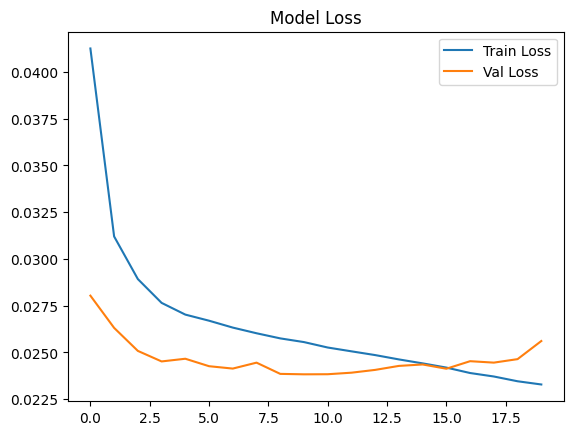

In [22]:
model = Sequential()

# Tăng units lên 128 để đủ sức học 8 features
model.add(LSTM(128, activation='relu', return_sequences=True, 
               input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))

model.add(LSTM(64, activation='relu'))
model.add(Dropout(0.2))

# Output Layer: 8 neurons
model.add(Dense(len(TARGET_COLS)))

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Train
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

# Vẽ biểu đồ Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()
plt.show()

Đang chạy kiểm thử Recursive (sẽ mất thời gian)...

surface_pressure_mean: R2 = 0.7058 | MAE = 0.3842
wind_speed_10m_mean: R2 = 0.4186 | MAE = 0.4266
cloudcover_mean: R2 = 0.3328 | MAE = 0.3753
temperature_2m_mean: R2 = 0.8362 | MAE = 0.2976
relative_humidity_2m_mean: R2 = 0.5629 | MAE = 0.3855
rain_sum: R2 = 0.2583 | MAE = 5.0008
precipitation_hours: R2 = 0.4040 | MAE = 3.9352
weather_code: R2 = 0.2978 | MAE = 0.2511


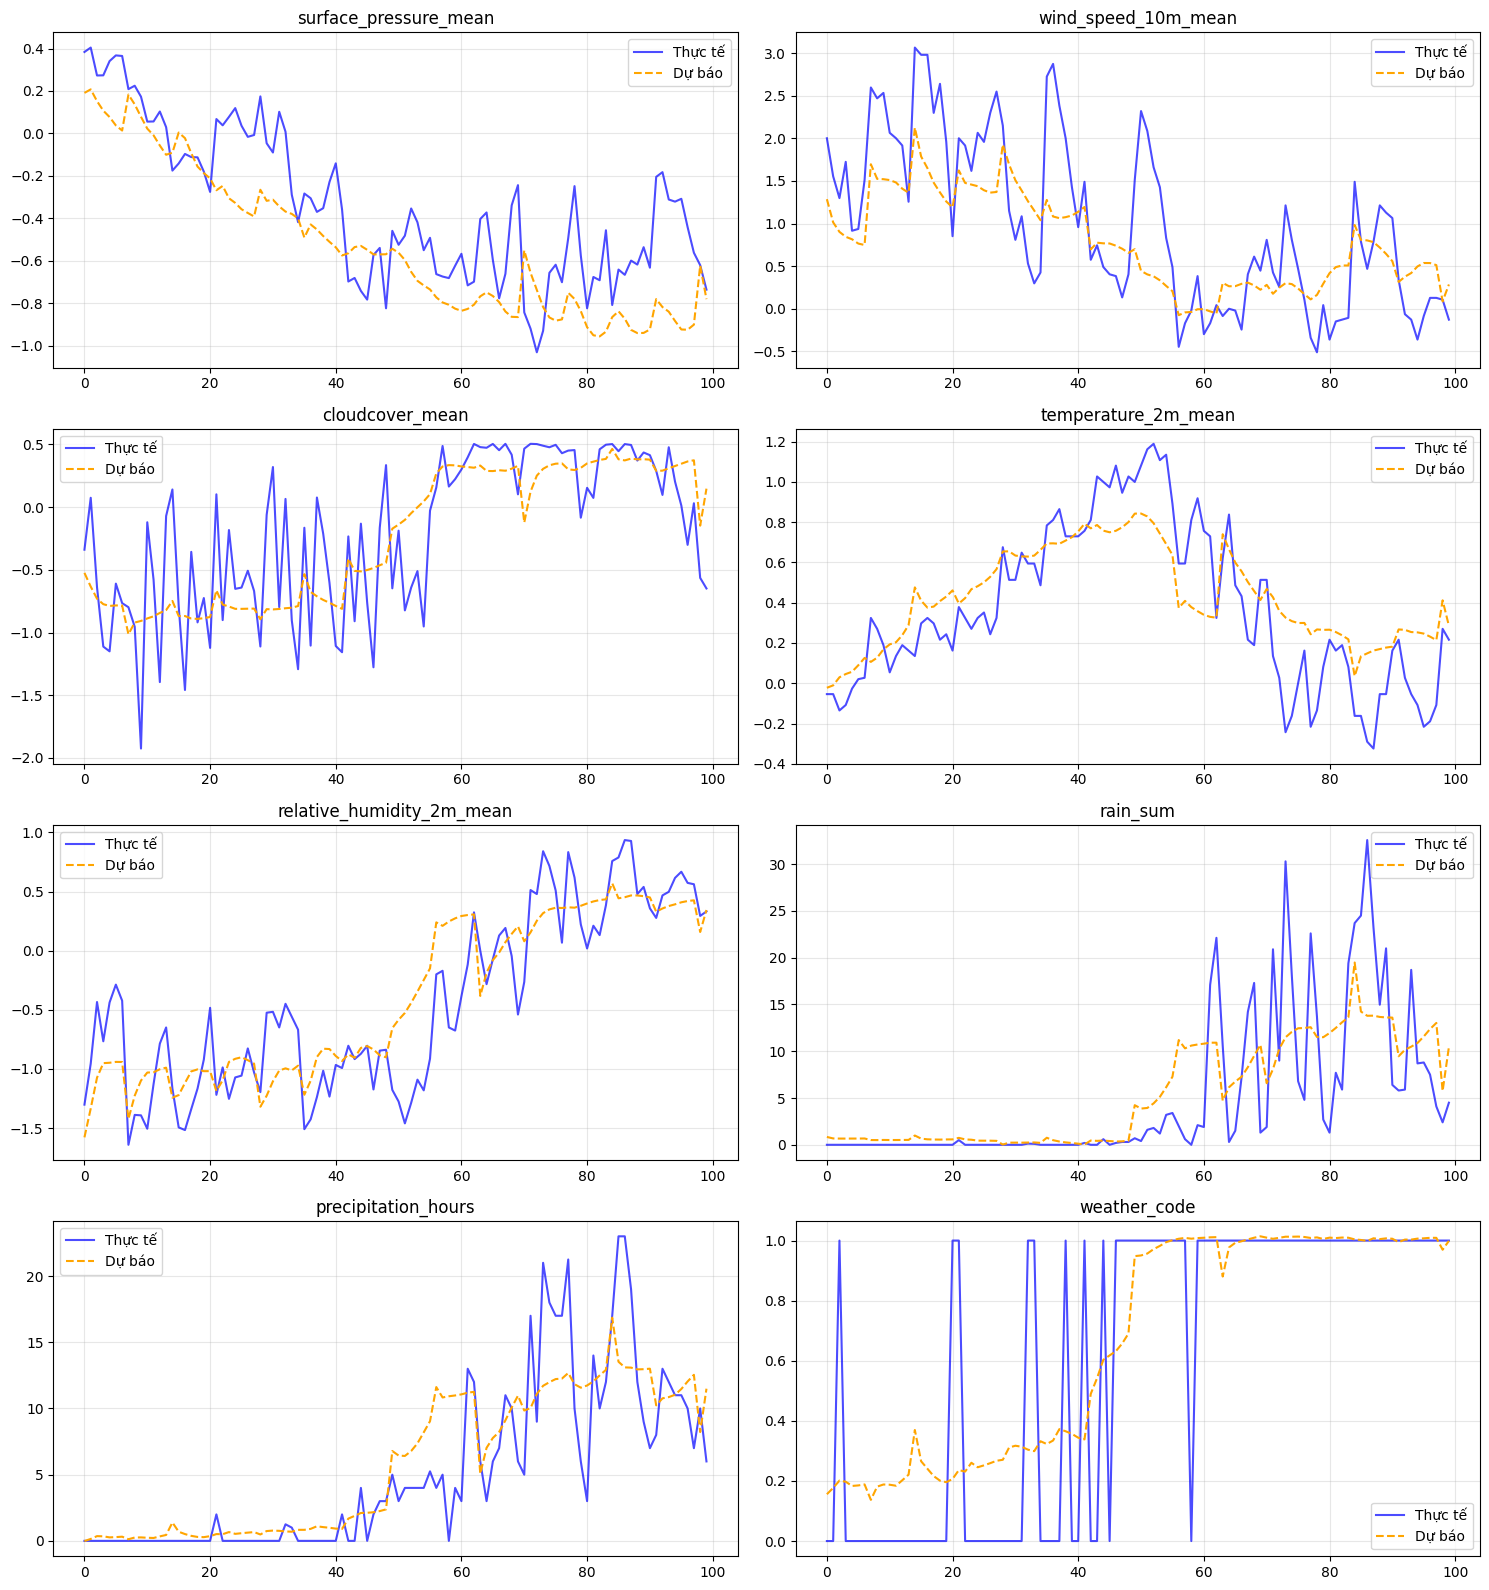

In [23]:
def recursive_predict(model, initial_sequence, days_to_predict, target_indices, future_exogenous):
    predictions = []
    current_seq = initial_sequence.copy()

    for i in range(days_to_predict):
        # Dự báo 1 ngày
        pred = model.predict(current_seq, verbose=0) 
        predictions.append(pred[0])

        # Cập nhật input: Lấy dữ liệu nền ngày sau + Ghi đè 8 giá trị vừa dự báo
        next_row = future_exogenous[i].copy()
        np.put(next_row, target_indices, pred[0]) 
        
        next_row = next_row.reshape(1, 1, -1)
        current_seq = np.append(current_seq[:, 1:, :], next_row, axis=1)

    return np.array(predictions)

# --- CHẠY TEST ---
test_predictions = []
test_actuals = []

print("Đang chạy kiểm thử Recursive (sẽ mất thời gian)...")
# Nhảy cóc 14 ngày để test nhanh
for i in range(0, len(X_test_scaled) - N_PAST - DAYS_TO_PREDICT, 14):
    init_seq = X_test_scaled[i : i + N_PAST].reshape(1, N_PAST, -1)
    future_exog = X_test_scaled[i + N_PAST : i + N_PAST + DAYS_TO_PREDICT]
    
    preds = recursive_predict(model, init_seq, DAYS_TO_PREDICT, target_indices, future_exog)
    actuals = future_exog[:, target_indices]
    
    test_predictions.append(scaler_y.inverse_transform(preds))
    test_actuals.append(scaler_y.inverse_transform(actuals))

test_predictions = np.concatenate(test_predictions)
test_actuals = np.concatenate(test_actuals)

# --- ĐÁNH GIÁ & VẼ HÌNH (Lưới 4x2) ---
print("\n" + "="*40)
for i, col in enumerate(TARGET_COLS):
    r2 = r2_score(test_actuals[:, i], test_predictions[:, i])
    mae = mean_absolute_error(test_actuals[:, i], test_predictions[:, i])
    print(f"{col}: R2 = {r2:.4f} | MAE = {mae:.4f}")

# Vẽ biểu đồ 8 subplot
cols_plot = 2
rows_plot = math.ceil(len(TARGET_COLS) / cols_plot)
days_idx = range(100) # Zoom 100 ngày đầu

plt.figure(figsize=(15, 4 * rows_plot))
for i, col in enumerate(TARGET_COLS):
    plt.subplot(rows_plot, cols_plot, i+1)
    plt.plot(days_idx, test_actuals[:100, i], label='Thực tế', color='blue', alpha=0.7)
    plt.plot(days_idx, test_predictions[:100, i], label='Dự báo', color='orange', linestyle='--')
    plt.title(f'{col}')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
# Đặt tên file model chung
model_base_name = "lstm_recursive_8_features"

# 1. Lưu Model Keras
model_path = os.path.join(BASE_MODEL_DIR, f"{model_base_name}.keras")
model.save(model_path)
print(f"Đã lưu Model tại: {model_path}")

# 2. Lưu Scaler X
scaler_x_path = os.path.join(BASE_MODEL_DIR, f"scaler_X_{model_base_name}.pkl")
with open(scaler_x_path, 'wb') as f:
    pickle.dump(scaler_X, f)

# 3. Lưu Scaler Y
scaler_y_path = os.path.join(BASE_MODEL_DIR, f"scaler_y_{model_base_name}.pkl")
with open(scaler_y_path, 'wb') as f:
    pickle.dump(scaler_y, f)
    
print("Hoàn tất lưu trữ!")

Đã lưu Model tại: ../models/rnn_recursive/lstm_recursive_8_features.keras
Hoàn tất lưu trữ!
